# **PART 1: Neural Network Fundamentals & Training Behaviour Analysis**

# Task 1: Dataset Understanding

In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import confusion_matrix, classification_report

In [297]:
# Loading the Dataset
df = pd.read_csv('customer_churn_nn.csv')
# Displayinh first 5 Rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [298]:
# Shape of Dataset
print('No. of Rows & Columns: ', df.shape)

No. of Rows & Columns:  (2000, 17)


In [299]:
# Data types of Features
df.dtypes

,0
customer_id,object
region,object
plan_type,object
contract_type,object
payment_method,object
tenure_months,int64
monthly_charges_inr,float64
avg_login_days_per_month,int64
support_tickets_last_90_days,int64
payment_delay_days,int64


In [300]:
# Target Variable Distribution
print(df['churn'].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


NOTE:

The target Variable is 'churn'
- 1 indicates that the customer churned.
- 0 indicates that the customer was retained

In [301]:
# Missing Value Check
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


In [302]:
# Statistical Summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


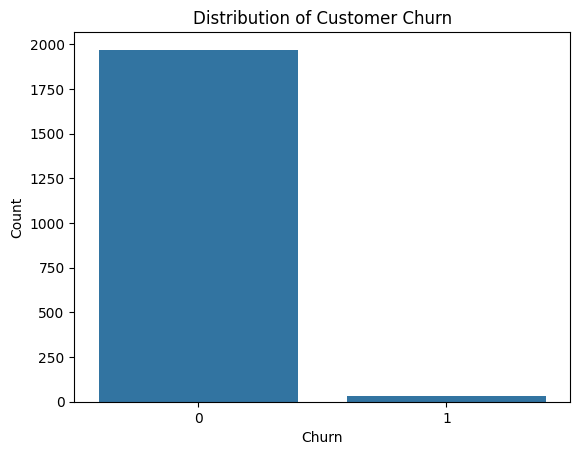

In [303]:
# Distribution of Target Variable
sns.countplot(x='churn', data=df)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

NOTE:

The graph shows the no. of customers who churned and those who stayed.

This helps in understanding whether the dataset is balanced before training the nueral network model.

# Task 2: Data Preprocessing

In [304]:
# Dropping customer_id column
df= df.drop('customer_id', axis=1)
df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [305]:
# Check Missing Values
print(df.isnull().sum())

region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


NOTE: No missing values were found in the dataset, so no additional missing value handling was required.

In [306]:
# Encoding Categorical Variables
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False
3,22,959.51,19,2,3,139.73,7.2,130,5,0,...,True,False,True,False,False,False,False,False,False,False
4,11,890.20,18,2,6,156.43,5.8,0,5,1,...,False,False,True,False,False,False,False,True,False,False


In [307]:
# Seperate Input Features & Target Variable
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

In [308]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                test_size=0.2, random_state=42)
print('Training Data Shape: ', X_train.shape)
print('Testing Data Shape: ', X_test.shape)

Training Data Shape:  (1600, 24)
Testing Data Shape:  (400, 24)


In [309]:
# Scaling Numerical Features
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

NOTE: Preprocessing steps include:
 - Removing the customer identifier column
 - Checking for missing values
 - Encoding categorical values using one-hot encoding
 - Spliiting the dataset into training
 - Testing sets and scaling the features using StandardScalar

# Task 3: Neural Network Model Building

In [310]:
# Building the neural network model
model = Sequential()

# Input layer + hidden layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compiling the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

NOTE:
 The neural network model consists of:
- An input layer connected to the first hidden layer
- Two hidden layers using the ReLU activation function
- An output layer with sigmoid activation for binary classification

The model uses:
- Adam optimizer
- Binary crossentropy loss function
- Accuracy as the evaluation metric

# Task 4: Training & Evaluation

In [311]:
# Training the neural network model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9867 - loss: 3.0541 - val_accuracy: 0.9781 - val_loss: 4.6330
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 2.0757 - val_accuracy: 0.9781 - val_loss: 2.8585
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 1.1404 - val_accuracy: 0.9781 - val_loss: 1.4261
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.4478 - val_accuracy: 0.9781 - val_loss: 0.3707
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1632 - val_accuracy: 0.9781 - val_loss: 0.1783
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1271 - val_accuracy: 0.9781 - val_loss: 0.1622
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1071 - val_accuracy: 0.9781 - val_loss: 0.1478
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.1024 - val_accuracy: 0.9781 - val_loss:

In [312]:
# Evaluating model on test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9825 - loss: 0.0794  
Test Loss: 0.07939188182353973
Test Accuracy: 0.9825000166893005


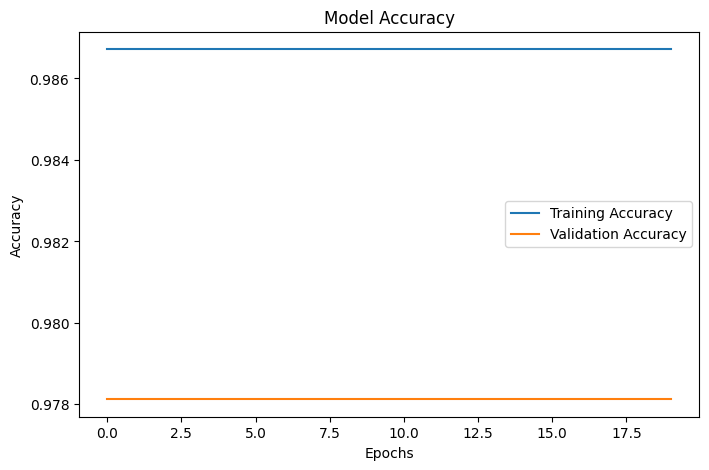

In [313]:
# Plotting training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

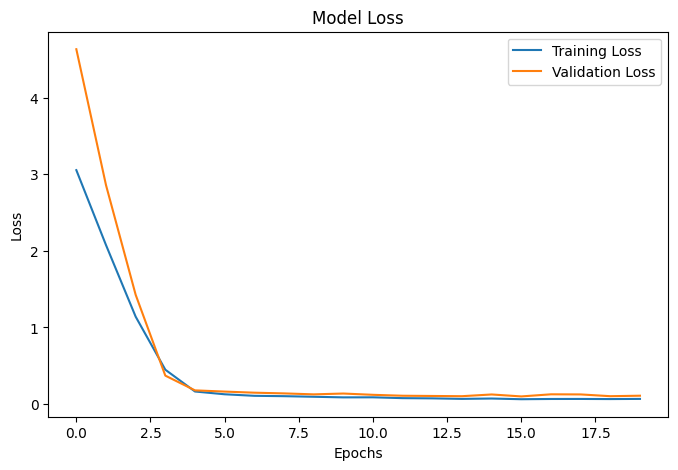

In [314]:
# Plotting training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [315]:
# Making predictions
y_pred = model.predict(X_test)

# Converting probabilities into binary predictions
y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


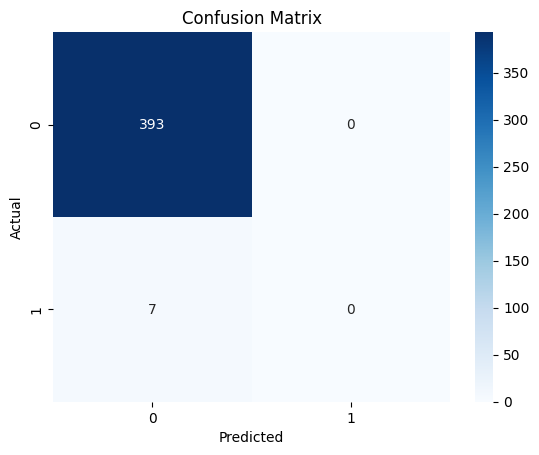

In [316]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [317]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NOTE:

The neural network model achieved good performance on the test dataset.

The accuracy and loss curves indicate how the model improved during training.

The confusion matrix and classification report help evaluate how well the model classified customers who churned and those who stayed.

# Task 5: Hyperparameter Experimentation

In [318]:
# Experiment 1

model_1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')])
model_1.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
history_1 = model_1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0)
loss_1, accuracy_1 = model_1.evaluate(X_test, y_test, verbose=0)
print("Experiment 1 Accuracy:", accuracy_1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 Accuracy: 0.9800000190734863


In [319]:
# Experiment 2

model_2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')])
model_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
history_2 = model_2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=0)
loss_2, accuracy_2 = model_2.evaluate(X_test, y_test, verbose=0)
print("Experiment 2 Accuracy:", accuracy_2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 2 Accuracy: 0.9825000166893005


In [320]:
# Experiment 3

model_3 = Sequential([
    Dense(16, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(8, activation='tanh'),
    Dense(1, activation='sigmoid')])
model_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
history_3 = model_3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=0)
loss_3, accuracy_3 = model_3.evaluate(X_test, y_test, verbose=0)
print("Experiment 3 Accuracy:", accuracy_3)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 3 Accuracy: 0.9825000166893005


In [321]:
# Creating comparison table

comparison_table = pd.DataFrame({
    'Experiment': [
        'Experiment 1',
        'Experiment 2',
        'Experiment 3'],
    'Configuration': [
        '16-8 neurons, relu, 20 epochs',
        '32-16 neurons, relu, 20 epochs',
        '16-8 neurons, tanh, 30 epochs'],
    'Test Accuracy': [
        accuracy_1,
        accuracy_2,
        accuracy_3]})
comparison_table

,Experiment,Configuration,Test Accuracy
0,Experiment 1,"16-8 neurons, relu, 20 epochs",0.9800
1,Experiment 2,"32-16 neurons, relu, 20 epochs",0.9825
2,Experiment 3,"16-8 neurons, tanh, 30 epochs",0.9825


In [322]:
# Saving comparison table
comparison_table.to_csv('model_comparison_table.csv', index=False)

NOTE: Different hyperparameter configurations resulted in slight changes in model performance.

 Increasing the number of neurons and modifying activation functions affected the learning behavior and accuracy of the neural network.

# Task 6: Final Reflection

### Role of Weights and Biases
Weights help the neural network learn the importance of each input feature during training. Biases allow the model to shift the activation function and improve flexibility in learning patterns from the data.

### Importance of Activation Functions
Activation functions introduce non-linearity into the neural network. Without activation functions, the model would behave like a simple linear model and would not be able to learn complex relationships in the dataset.

### Effect of Learning Rate
If the learning rate is too high, the model may overshoot the optimal solution and training may become unstable. If the learning rate is too low, training becomes very slow and the model may take a long time to converge.

### Underfitting and Overfitting
The model did not show significant underfitting or overfitting. The training and validation accuracy remained close to each other, indicating that the model generalized reasonably well on unseen test data.